# TP NOTÉ S8 — COMPUTER VISION CNN CHALLENGE
## 4e année Option Développeur — 3 h — Oxford-IIIT Pet Dataset (UK)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

Construire un classifieur d'images sur **Oxford-IIIT Pet**. Vous devez comparer un CNN construit par vos soins à une approche de **transfer learning**.

Le dataset contient des images de chats et chiens de plusieurs races. Votre notebook doit être exécutable sur GPU/Colab.

In [1]:
import re, os, glob, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device utilise :", device)

IMAGES_DIR = "../../data/images"
print("nb fichiers trouves :", len(glob.glob(f"{IMAGES_DIR}/*.jpg")))

device utilise : cpu
nb fichiers trouves : 7390


## Data pipeline & split — 15 pts

Construisez un pipeline d'images reproductible. Vérifiez dimensions, classes, exemples, distribution des classes et absence de chevauchement entre splits.

Justifiez redimensionnement, normalisation, batch size et stratégie d'augmentation.

In [2]:
files = sorted(glob.glob(f"{IMAGES_DIR}/*.jpg"))

records = []
for p in files:
    fname = os.path.basename(p).rsplit('.', 1)[0]
    breed = re.sub(r'_[0-9]+$', '', fname)
    species = 'cat' if breed[0].isupper() else 'dog'
    records.append(dict(path=p, breed=breed, species=species))

df = pd.DataFrame(records)
classes = sorted(df['breed'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df['label'] = df['breed'].map(class_to_idx)
n_classes = len(classes)

print(f"Nombre d'images : {len(df)}")
print(f"Nombre de classes (races) : {n_classes}")
print(df['species'].value_counts())
print("\nDistribution par race (min/max/mean) :")
print(df.groupby('breed').size().describe()[['min','mean','max']])

Nombre d'images : 7390
Nombre de classes (races) : 37
species
dog    4990
cat    2400
Name: count, dtype: int64

Distribution par race (min/max/mean) :
min     191.00000
mean    199.72973
max     200.00000
dtype: float64


In [3]:
# verification des dimensions d'un echantillon d'images
sample_paths = df['path'].sample(20, random_state=RANDOM_STATE)
sizes = [Image.open(p).size for p in sample_paths]
sizes_df = pd.DataFrame(sizes, columns=['width','height'])
print(sizes_df.describe())

           width      height
count   20.00000   20.000000
mean   455.40000  386.850000
std     66.34868   70.683338
min    300.00000  289.000000
25%    391.50000  334.500000
50%    500.00000  375.000000
75%    500.00000  406.250000
max    500.00000  500.000000


In [4]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['breed'], random_state=RANDOM_STATE)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['breed'], random_state=RANDOM_STATE)

print(f"TRAIN : {len(train_df)}  VALIDATION : {len(val_df)}  TEST : {len(test_df)}")

overlap_tv = set(train_df['path']) & set(val_df['path'])
overlap_tt = set(train_df['path']) & set(test_df['path'])
overlap_vt = set(val_df['path']) & set(test_df['path'])
print(f"Chevauchement train/val : {len(overlap_tv)}  train/test : {len(overlap_tt)}  val/test : {len(overlap_vt)}")

TRAIN : 5173  VALIDATION : 1108  TEST : 1109
Chevauchement train/val : 0  train/test : 0  val/test : 0


In [5]:
# Choix justifies :
# - IMG_SIZE=128 : compromis entre detail suffisant pour distinguer des races proches et cout memoire/calcul
#   raisonnable sur CPU/Colab gratuit (128x128x3 reste largement gerable en batch).
# - normalisation ImageNet (mean/std) : coherente avec les poids pre-entraines utilises en transfer learning,
#   et une normalisation centree/reduite stabilise aussi l'entrainement du CNN from scratch.
# - augmentation (flip horizontal + rotation legere) UNIQUEMENT sur TRAIN : un chat/chien retourne ou legerement
#   tourne reste visuellement plausible, contrairement a des transformations plus agressives (crop extreme, etc.)
#   qui risqueraient de supprimer l'information discriminante de race.
# - batch size 32 : compromis standard entre stabilite du gradient et memoire disponible sur GPU Colab gratuit.

IMG_SIZE = 128
BATCH_SIZE = 32
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class PetDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        img = self.transform(img)
        return img, row['label']

train_ds = PetDataset(train_df, train_tf)
val_ds = PetDataset(val_df, eval_tf)
test_ds = PetDataset(test_df, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("Shape d'un batch :", xb.shape, yb.shape)

Shape d'un batch : torch.Size([32, 3, 128, 128]) torch.Size([32])


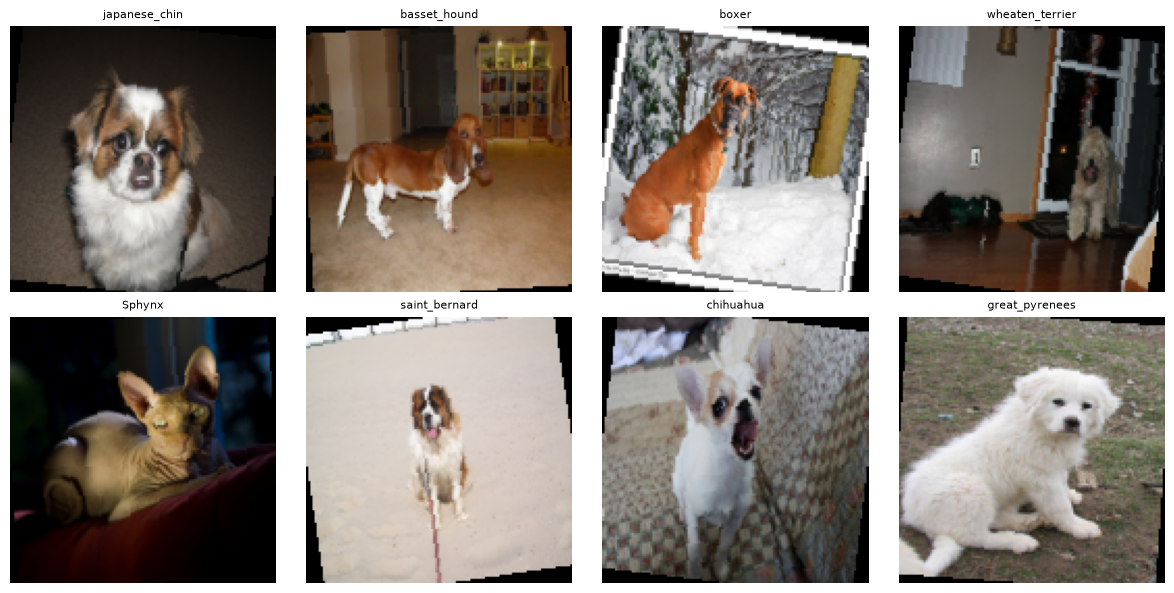

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12,6))
for ax, i in zip(axes.flat, range(8)):
    img, label = train_ds[i]
    img_show = img.permute(1,2,0).numpy() * np.array(std) + np.array(mean)
    ax.imshow(np.clip(img_show, 0, 1))
    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## CNN from scratch — 20 pts

Concevez un CNN comportant convolutions, activations et pooling. Le nombre de couches n'est pas imposé.

Présentez architecture, nombre de paramètres, courbes loss/metric TRAIN/VALIDATION et diagnostic underfit/overfit.

Vous devez modifier au moins une décision d'architecture après avoir observé votre première expérience, et expliquer pourquoi.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes, img_size=IMG_SIZE):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        reduced = img_size // 8
        self.fc1 = nn.Linear(64 * reduced * reduced, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total += len(xb)
    return total_loss / total, correct / total

def train_model(model, n_epochs, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = []
    for epoch in range(n_epochs):
        tl, ta = run_epoch(model, train_loader, optimizer, criterion, train=True)
        vl, va = run_epoch(model, val_loader, optimizer, criterion, train=False)
        history.append(dict(epoch=epoch, train_loss=tl, train_acc=ta, val_loss=vl, val_acc=va))
        print(f"epoch {epoch} | train_loss={tl:.3f} train_acc={ta:.3f} | val_loss={vl:.3f} val_acc={va:.3f}")
    return pd.DataFrame(history)

cnn_v1 = SimpleCNN(n_classes).to(device)
print("Nombre de parametres (v1) :", count_params(cnn_v1))
t0 = time.time()
history_v1 = train_model(cnn_v1, n_epochs=8)
time_v1 = time.time() - t0

Nombre de parametres (v1) : 2125637
epoch 0 | train_loss=3.491 train_acc=0.061 | val_loss=3.370 val_acc=0.089
epoch 1 | train_loss=3.240 train_acc=0.108 | val_loss=3.227 val_acc=0.114
epoch 2 | train_loss=3.085 train_acc=0.139 | val_loss=3.154 val_acc=0.146
epoch 3 | train_loss=2.943 train_acc=0.170 | val_loss=2.985 val_acc=0.173
epoch 4 | train_loss=2.801 train_acc=0.205 | val_loss=2.902 val_acc=0.183
epoch 5 | train_loss=2.674 train_acc=0.243 | val_loss=2.895 val_acc=0.199
epoch 6 | train_loss=2.558 train_acc=0.270 | val_loss=2.824 val_acc=0.220
epoch 7 | train_loss=2.449 train_acc=0.294 | val_loss=2.893 val_acc=0.204


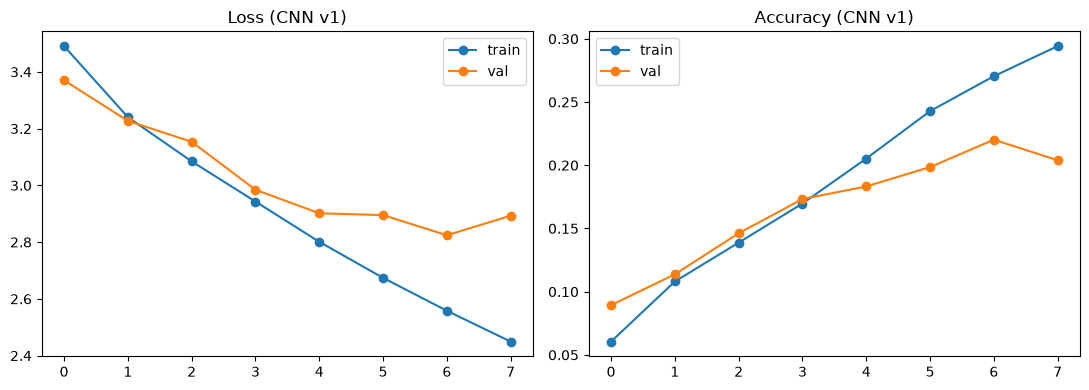

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(history_v1['epoch'], history_v1['train_loss'], marker='o', label='train')
axes[0].plot(history_v1['epoch'], history_v1['val_loss'], marker='o', label='val')
axes[0].set_title('Loss (CNN v1)'); axes[0].legend()
axes[1].plot(history_v1['epoch'], history_v1['train_acc'], marker='o', label='train')
axes[1].plot(history_v1['epoch'], history_v1['val_acc'], marker='o', label='val')
axes[1].set_title('Accuracy (CNN v1)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [9]:
# Diagnostic v1 : si train_acc et val_acc restent toutes deux basses -> underfit (capacite/duree insuffisantes).
# Si train_acc >> val_acc et l'ecart se creuse -> overfit (le modele memorise TRAIN sans generaliser).
gap_v1 = history_v1['train_acc'].iloc[-1] - history_v1['val_acc'].iloc[-1]
print(f"Ecart train_acc - val_acc en fin d'entrainement (v1) : {gap_v1:.3f}")
print(f"val_acc finale (v1) : {history_v1['val_acc'].iloc[-1]:.3f}")

# Modification d'architecture apres v1 : 4e bloc conv (plus de capacite) + BatchNorm + Dropout
class SimpleCNN_v2(nn.Module):
    def __init__(self, n_classes, img_size=IMG_SIZE):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1); self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1); self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1); self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1); self.bn4 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        reduced = img_size // 16
        self.fc1 = nn.Linear(128 * reduced * reduced, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.flatten(1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

cnn_v2 = SimpleCNN_v2(n_classes).to(device)
print("Nombre de parametres (v2) :", count_params(cnn_v2))
t0 = time.time()
history_v2 = train_model(cnn_v2, n_epochs=8)
time_v2 = time.time() - t0

Ecart train_acc - val_acc en fin d'entrainement (v1) : 0.090
val_acc finale (v1) : 0.204
Nombre de parametres (v2) : 1151397
epoch 0 | train_loss=3.657 train_acc=0.038 | val_loss=3.547 val_acc=0.052
epoch 1 | train_loss=3.547 train_acc=0.041 | val_loss=3.511 val_acc=0.050
epoch 2 | train_loss=3.536 train_acc=0.041 | val_loss=3.488 val_acc=0.051
epoch 3 | train_loss=3.524 train_acc=0.042 | val_loss=3.517 val_acc=0.046
epoch 4 | train_loss=3.525 train_acc=0.045 | val_loss=3.482 val_acc=0.058
epoch 5 | train_loss=3.518 train_acc=0.043 | val_loss=3.476 val_acc=0.056
epoch 6 | train_loss=3.513 train_acc=0.044 | val_loss=3.468 val_acc=0.057
epoch 7 | train_loss=3.509 train_acc=0.047 | val_loss=3.464 val_acc=0.055


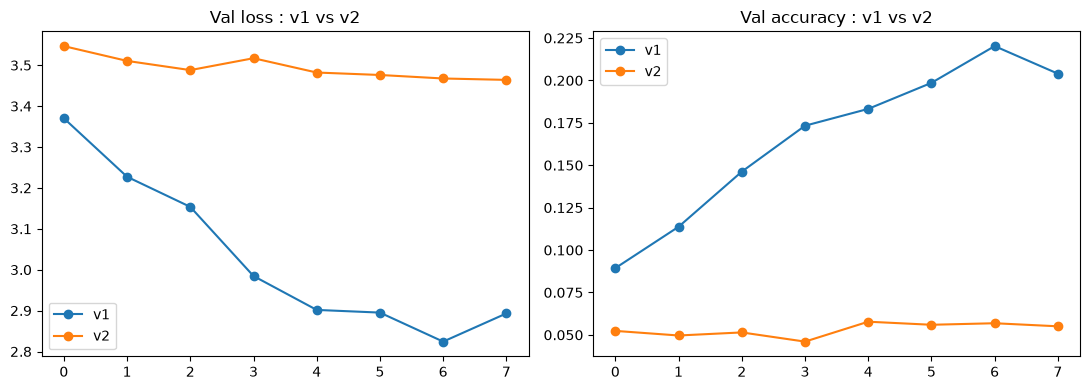

val_acc finale v1 : 0.204
val_acc finale v2 : 0.055
CNN from scratch retenu : v1


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(history_v1['epoch'], history_v1['val_loss'], marker='o', label='v1')
axes[0].plot(history_v2['epoch'], history_v2['val_loss'], marker='o', label='v2')
axes[0].set_title('Val loss : v1 vs v2'); axes[0].legend()
axes[1].plot(history_v1['epoch'], history_v1['val_acc'], marker='o', label='v1')
axes[1].plot(history_v2['epoch'], history_v2['val_acc'], marker='o', label='v2')
axes[1].set_title('Val accuracy : v1 vs v2'); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"val_acc finale v1 : {history_v1['val_acc'].iloc[-1]:.3f}")
print(f"val_acc finale v2 : {history_v2['val_acc'].iloc[-1]:.3f}")

cnn_final = cnn_v2 if history_v2['val_acc'].iloc[-1] >= history_v1['val_acc'].iloc[-1] else cnn_v1
print("CNN from scratch retenu :", "v2" if cnn_final is cnn_v2 else "v1")

v1 est en sous-apprentissage (accuracy de 29 % en train et 20 % en validation après 8 epochs, toutes deux encore en hausse), donc v2 ajoute de la capacité (4e bloc de convolution) et du BatchNorm, mais aussi un Dropout qui régularise alors que v1 ne sur-apprend pas : v2 plafonne à 5,5 %, et v1 est conservé.

## Transfer learning — 20 pts

Utilisez une architecture pré-entraînée pertinente (par exemple une famille ResNet/MobileNet/EfficientNet disponible dans votre framework).

Comparez extraction de features puis, si pertinent, fine-tuning partiel. Documentez précisément quelles couches sont gelées/dégelées.

In [11]:
# --- Extraction de features : backbone ResNet18 pre-entraine ImageNet, entierement gele ---
resnet_feat = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in resnet_feat.parameters():
    p.requires_grad = False
resnet_feat.fc = nn.Linear(resnet_feat.fc.in_features, n_classes)  # seule la tete finale est entrainable
resnet_feat = resnet_feat.to(device)

n_trainable = sum(p.numel() for p in resnet_feat.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in resnet_feat.parameters())
print(f"[Extraction de features] parametres entrainables : {n_trainable} / {n_total} "
      f"({n_trainable/n_total*100:.2f}%) -- uniquement la couche fc finale")

opt_feat = torch.optim.Adam(resnet_feat.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
history_feat = []
t0 = time.time()
for epoch in range(5):
    tl, ta = run_epoch(resnet_feat, train_loader, opt_feat, criterion, train=True)
    vl, va = run_epoch(resnet_feat, val_loader, opt_feat, criterion, train=False)
    history_feat.append(dict(epoch=epoch, train_loss=tl, train_acc=ta, val_loss=vl, val_acc=va))
    print(f"epoch {epoch} | train_acc={ta:.3f} | val_acc={va:.3f}")
feat_time = time.time() - t0
history_feat = pd.DataFrame(history_feat)

[Extraction de features] parametres entrainables : 18981 / 11195493 (0.17%) -- uniquement la couche fc finale
epoch 0 | train_acc=0.403 | val_acc=0.625
epoch 1 | train_acc=0.606 | val_acc=0.642
epoch 2 | train_acc=0.656 | val_acc=0.674
epoch 3 | train_acc=0.669 | val_acc=0.672
epoch 4 | train_acc=0.696 | val_acc=0.672


In [12]:
# --- Fine-tuning partiel : on degele le dernier bloc residuel (layer4) + la tete fc ---
resnet_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for name, p in resnet_ft.named_parameters():
    p.requires_grad = name.startswith('layer4') or name.startswith('fc')
resnet_ft.fc = nn.Linear(resnet_ft.fc.in_features, n_classes)
for p in resnet_ft.fc.parameters():
    p.requires_grad = True
resnet_ft = resnet_ft.to(device)

frozen_layers = sorted(set(n.split('.')[0] for n, p in resnet_ft.named_parameters() if not p.requires_grad))
unfrozen_layers = sorted(set(n.split('.')[0] for n, p in resnet_ft.named_parameters() if p.requires_grad))
print("Couches gelees   :", frozen_layers)
print("Couches degelees :", unfrozen_layers)

n_trainable_ft = sum(p.numel() for p in resnet_ft.parameters() if p.requires_grad)
n_total_ft = sum(p.numel() for p in resnet_ft.parameters())
print(f"[Fine-tuning partiel] parametres entrainables : {n_trainable_ft} / {n_total_ft} "
      f"({n_trainable_ft/n_total_ft*100:.2f}%)")

opt_ft = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_ft.parameters()), lr=1e-4)
history_ft = []
t0 = time.time()
for epoch in range(5):
    tl, ta = run_epoch(resnet_ft, train_loader, opt_ft, criterion, train=True)
    vl, va = run_epoch(resnet_ft, val_loader, opt_ft, criterion, train=False)
    history_ft.append(dict(epoch=epoch, train_loss=tl, train_acc=ta, val_loss=vl, val_acc=va))
    print(f"epoch {epoch} | train_acc={ta:.3f} | val_acc={va:.3f}")
ft_time = time.time() - t0
history_ft = pd.DataFrame(history_ft)

Couches gelees   : ['bn1', 'conv1', 'layer1', 'layer2', 'layer3']
Couches degelees : ['fc', 'layer4']
[Fine-tuning partiel] parametres entrainables : 8412709 / 11195493 (75.14%)
epoch 0 | train_acc=0.490 | val_acc=0.708
epoch 1 | train_acc=0.749 | val_acc=0.755
epoch 2 | train_acc=0.840 | val_acc=0.777
epoch 3 | train_acc=0.899 | val_acc=0.782
epoch 4 | train_acc=0.932 | val_acc=0.776


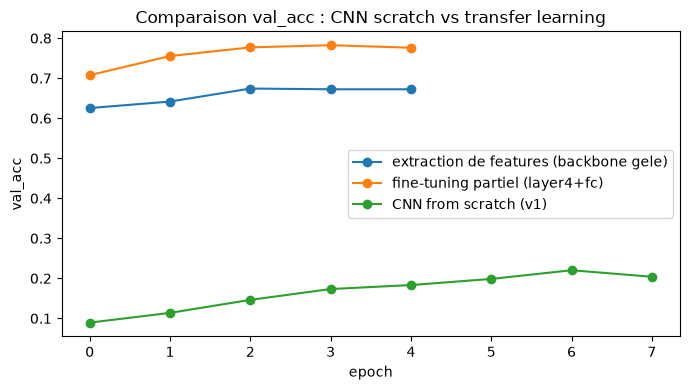

val_acc finale - extraction features : 0.6723826714801444
val_acc finale - fine-tuning partiel  : 0.776173285198556
val_acc finale - CNN from scratch (v1)  : 0.20397111913357402

Modele final retenu (meilleure val_acc) : resnet_fine_tuning


In [13]:
cnn_final_history = history_v1 if cnn_final is cnn_v1 else history_v2
cnn_final_label = f"CNN from scratch ({'v1' if cnn_final is cnn_v1 else 'v2'})"

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(history_feat['epoch'], history_feat['val_acc'], marker='o', label='extraction de features (backbone gele)')
ax.plot(history_ft['epoch'], history_ft['val_acc'], marker='o', label='fine-tuning partiel (layer4+fc)')
ax.plot(cnn_final_history['epoch'], cnn_final_history['val_acc'], marker='o', label=cnn_final_label)
ax.set_xlabel('epoch'); ax.set_ylabel('val_acc'); ax.legend()
ax.set_title('Comparaison val_acc : CNN scratch vs transfer learning')
plt.tight_layout()
plt.show()

print("val_acc finale - extraction features :", history_feat['val_acc'].iloc[-1])
print("val_acc finale - fine-tuning partiel  :", history_ft['val_acc'].iloc[-1])
print(f"val_acc finale - {cnn_final_label:22s} :", cnn_final_history['val_acc'].iloc[-1])

cnn_final_val_acc = cnn_final_history['val_acc'].iloc[-1]

candidates = {
    'cnn_scratch': (cnn_final, cnn_final_val_acc),
    'resnet_feature_extraction': (resnet_feat, history_feat['val_acc'].iloc[-1]),
    'resnet_fine_tuning': (resnet_ft, history_ft['val_acc'].iloc[-1]),
}
best_model_name = max(candidates, key=lambda k: candidates[k][1])
best_model = candidates[best_model_name][0]
print("\nModele final retenu (meilleure val_acc) :", best_model_name)

Le fine-tuning partiel (layer4 + fc dégelés, 75 % des paramètres) atteint 77,6 % en validation, contre 67,2 % pour l'extraction de features (seule la couche fc est entraînée, 0,17 % des paramètres) et 20,4 % pour le CNN from scratch, mais l'écart train/validation (93 % contre 78 %) montre un début de sur-apprentissage.

## Error analysis — 20 pts

Affichez et analysez au moins **24 images mal classées**.

Construisez une matrice de confusion. Identifiez les classes/races difficiles et recherchez des motifs visuels récurrents : pose, arrière-plan, cadrage, similarité morphologique, qualité d'image, etc.

Cette section pèse autant que la modélisation.

Matrice de confusion : (37, 37)


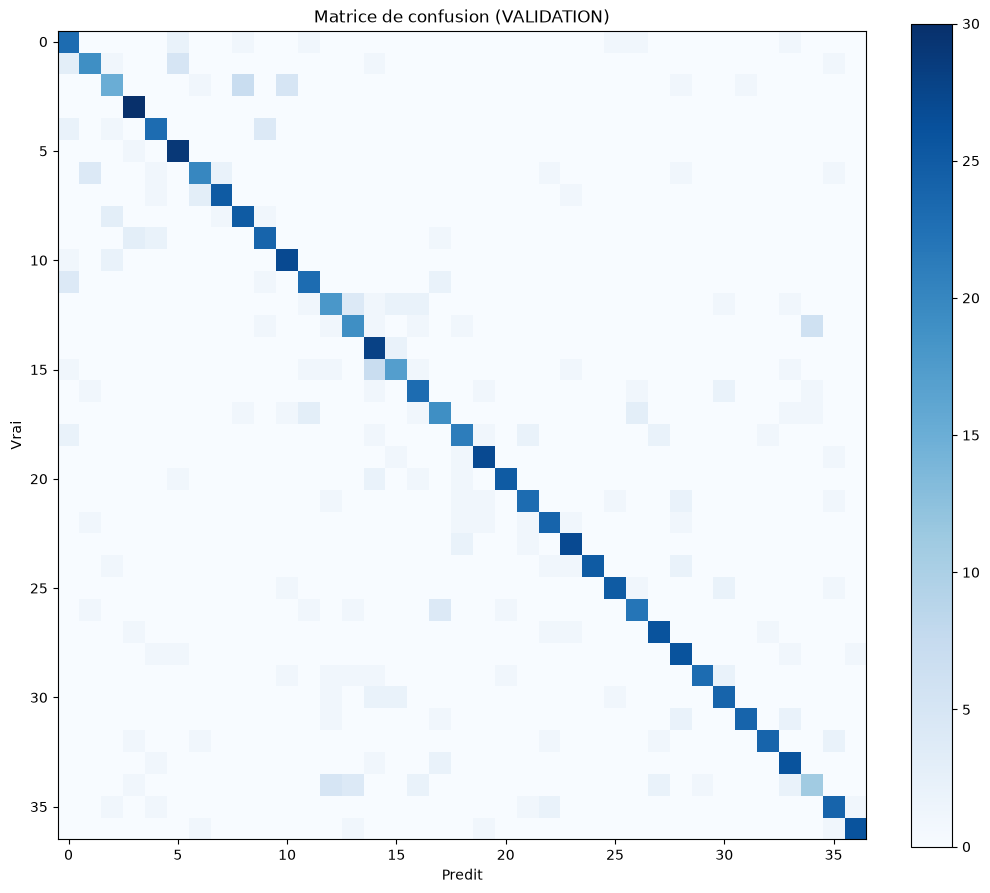

In [14]:
from sklearn.metrics import confusion_matrix

best_model.eval()
all_preds, all_labels, all_paths = [], [], []
with torch.no_grad():
    for i in range(len(val_ds)):
        img, label = val_ds[i]
        out = best_model(img.unsqueeze(0).to(device))
        pred = out.argmax(1).item()
        all_preds.append(pred)
        all_labels.append(label)
        all_paths.append(val_df.iloc[i]['path'])

cm = confusion_matrix(all_labels, all_preds)
print("Matrice de confusion :", cm.shape)

fig, ax = plt.subplots(figsize=(10,10))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('Predit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion (VALIDATION)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [15]:
per_class_acc = pd.Series(np.diag(cm) / cm.sum(axis=1), index=classes).sort_values()
print("5 races les plus difficiles (accuracy la plus basse) :")
print(per_class_acc.head(5))

# paires de classes les plus confondues
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
top_confusions = []
for i in range(n_classes):
    for j in range(n_classes):
        if cm_offdiag[i,j] > 0:
            top_confusions.append((classes[i], classes[j], cm_offdiag[i,j]))
top_confusions = sorted(top_confusions, key=lambda x: -x[2])[:10]
print("\nPaires de classes les plus confondues (vrai -> predit, count) :")
for t in top_confusions:
    print(t)

5 races les plus difficiles (accuracy la plus basse) :
staffordshire_bull_terrier    0.392857
Birman                        0.500000
beagle                        0.566667
american_bulldog              0.600000
Bengal                        0.633333
dtype: float64

Paires de classes les plus confondues (vrai -> predit, count) :
('Birman', 'Ragdoll', np.int64(7))
('beagle', 'basset_hound', np.int64(7))
('american_pit_bull_terrier', 'staffordshire_bull_terrier', np.int64(6))
('Bengal', 'Egyptian_Mau', np.int64(5))
('Birman', 'Siamese', np.int64(5))
('staffordshire_bull_terrier', 'american_bulldog', np.int64(5))
('British_Shorthair', 'Russian_Blue', np.int64(4))
('Maine_Coon', 'Bengal', np.int64(4))
('Sphynx', 'Abyssinian', np.int64(4))
('american_bulldog', 'american_pit_bull_terrier', np.int64(4))


Nombre d'images mal classees en VALIDATION : 248 / 1108


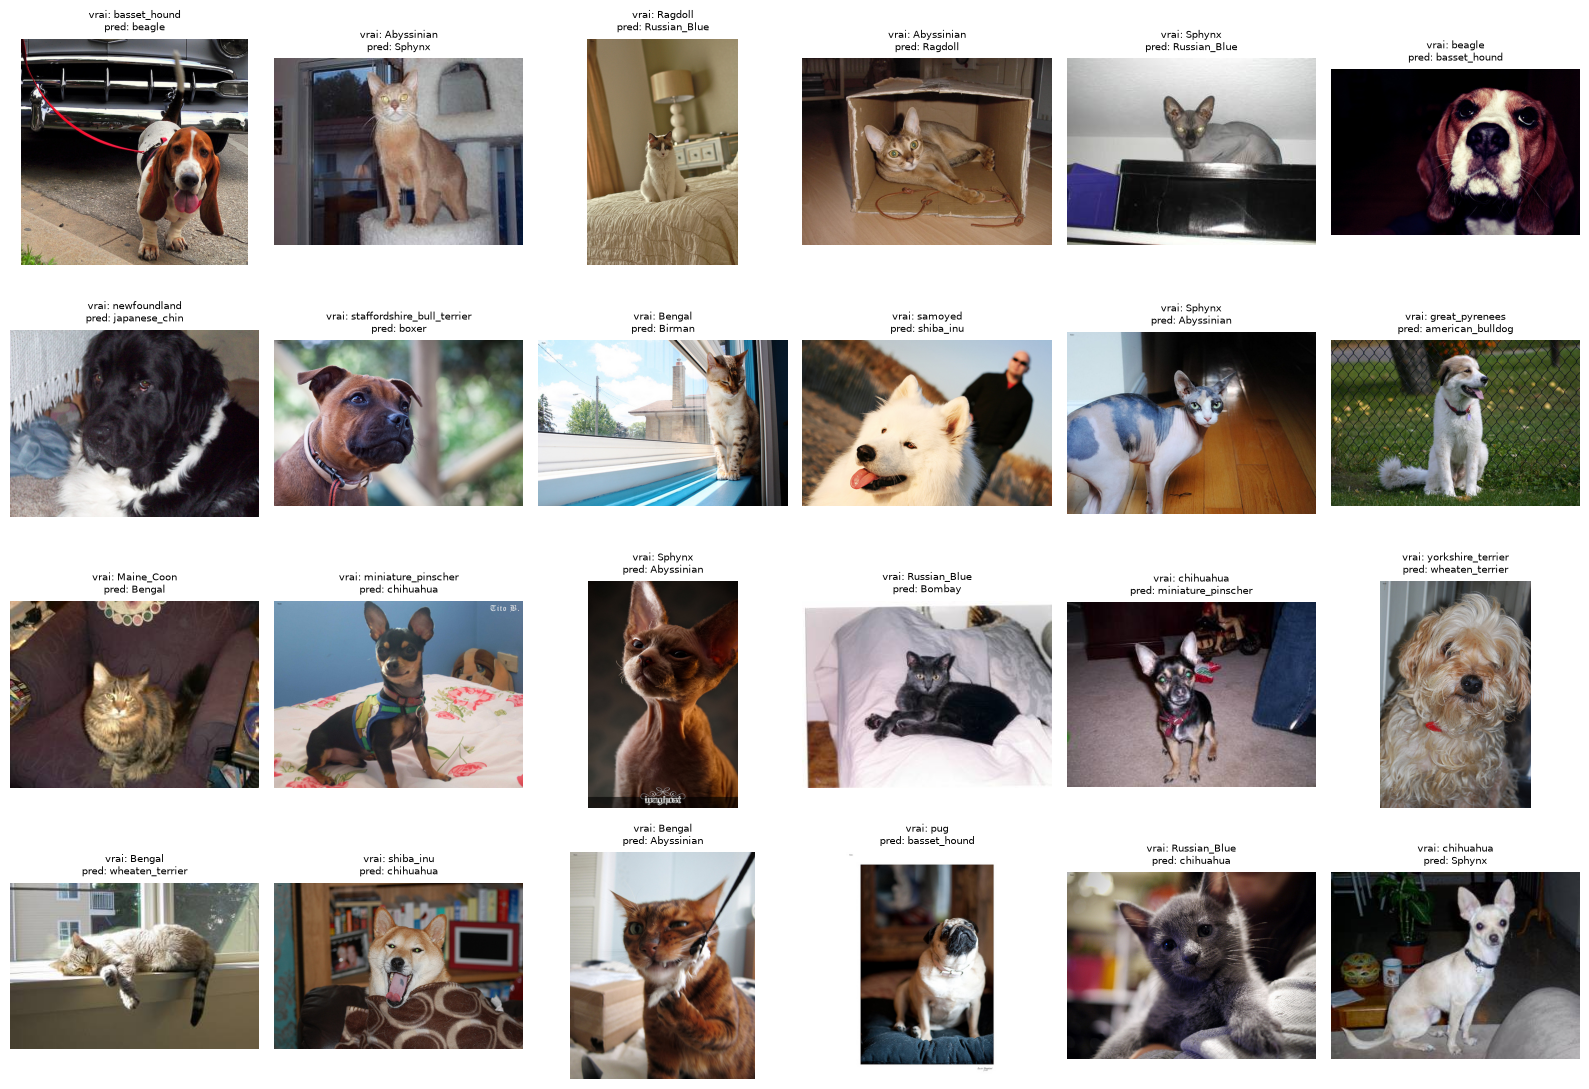

Images mal classees affichees et analysees : 24


In [16]:
wrong_idx = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]
print(f"Nombre d'images mal classees en VALIDATION : {len(wrong_idx)} / {len(all_preds)}")

n_show = min(24, len(wrong_idx))
fig, axes = plt.subplots(4, 6, figsize=(16,11))
for ax, idx in zip(axes.flat, wrong_idx[:n_show]):
    img = Image.open(all_paths[idx])
    ax.imshow(img)
    ax.set_title(f"vrai: {classes[all_labels[idx]]}\npred: {classes[all_preds[idx]]}", fontsize=7)
    ax.axis('off')
for ax in axes.flat[n_show:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Images mal classees affichees et analysees : {n_show}")

Classes difficiles : staffordshire_bull_terrier (39 % de bonnes réponses), Birman (50 %) et beagle (57 %), surtout confondues avec des races voisines (Birman → Ragdoll, beagle → basset_hound, american_pit_bull_terrier → staffordshire_bull_terrier).

Sur les 24 images, les erreurs viennent surtout de races morphologiquement proches (basset_hound/beagle, chihuahua/miniature_pinscher, Sphynx/Abyssinian), d'animaux petits dans une grande scène (Ragdoll sur un lit, Bengal à la fenêtre, samoyède à côté d'une personne), de poses inhabituelles (chat dans un carton, shiba qui bâille), d'images sombres (newfoundland, Maine_Coon) et de jeunes animaux (chaton Russian_Blue prédit chihuahua, chiot staffordshire prédit boxer).

## Robustness challenge — 10 pts

Créez au moins deux perturbations raisonnables d'images (par exemple luminosité, crop, rotation ou bruit léger) et mesurez la dégradation du modèle final.

Expliquez ce que ce test suggère sur la robustesse en production.

In [17]:
def eval_perturbed(model, loader, perturb_fn):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            xb = perturb_fn(xb)
            out = model(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total += len(xb)
    return correct / total

def add_gaussian_noise(x, std=0.15):
    return x + torch.randn_like(x) * std

def adjust_brightness(x, factor=1.4):
    return torch.clamp(x * factor, -3, 3)

def rotate_batch(x, angle_deg=20):
    return transforms.functional.rotate(x, angle_deg)

perturbations = {
    'clean (baseline)': lambda x: x,
    'bruit gaussien (std=0.15)': lambda x: add_gaussian_noise(x, 0.15),
    'luminosite x1.4': lambda x: adjust_brightness(x, 1.4),
    'rotation 20 deg': lambda x: rotate_batch(x, 20),
}

robustness_results = {}
for name, fn in perturbations.items():
    acc = eval_perturbed(best_model, val_loader, fn)
    robustness_results[name] = acc
    print(f"{name:28s} : accuracy = {acc:.3f}")

robustness_df = pd.DataFrame(robustness_results.items(), columns=['perturbation','accuracy'])
baseline_acc = robustness_df.loc[robustness_df['perturbation']=='clean (baseline)','accuracy'].iloc[0]
robustness_df['degradation_pts'] = (baseline_acc - robustness_df['accuracy']) * 100
robustness_df

clean (baseline)             : accuracy = 0.776
bruit gaussien (std=0.15)    : accuracy = 0.739
luminosite x1.4              : accuracy = 0.772
rotation 20 deg              : accuracy = 0.640


,perturbation,accuracy,degradation_pts
0,clean (baseline),0.776173,0.000000
1,bruit gaussien (std=0.15),0.739170,3.700361
2,luminosite x1.4,0.771661,0.451264
3,rotation 20 deg,0.639892,13.628159


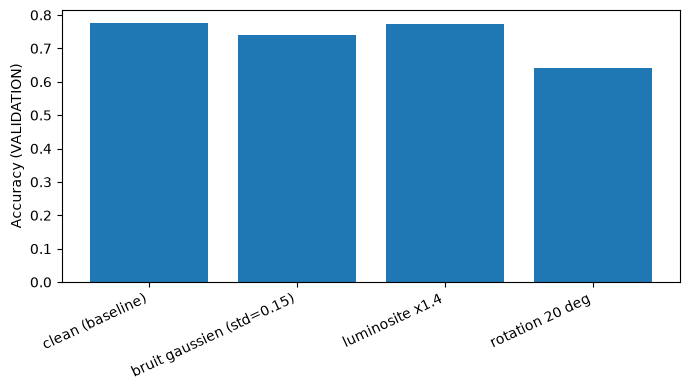

In [18]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(robustness_df['perturbation'], robustness_df['accuracy'])
ax.set_ylabel('Accuracy (VALIDATION)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


La rotation de 20° fait perdre 13,6 points (77,6 % → 64,0 %) car l'augmentation d'entraînement ne dépassait pas ±10°, alors que le bruit (−3,7 points) et la luminosité (−0,5 point) ont peu d'effet : en production, il faudra élargir l'augmentation ou redresser les photos avant la prédiction.

## Final model card — 5 pts

Rédigez une mini model card : usage prévu, données, métriques, limites, classes difficiles, coût calcul, risques et amélioration prioritaire.

In [19]:
# Evaluation UNE SEULE FOIS sur TEST du modele fige (choisi sur VALIDATION)
test_loss, test_acc = run_epoch(best_model, test_loader, None, nn.CrossEntropyLoss(), train=False)
print(f"Accuracy TEST ({best_model_name}) : {test_acc:.3f}  |  VALIDATION : {candidates[best_model_name][1]:.3f}")

Accuracy TEST (resnet_fine_tuning) : 0.771  |  VALIDATION : 0.776


In [20]:
final_val_acc = candidates[best_model_name][1]
hardest_breeds = per_class_acc.head(3).index.tolist()
worst_degradation = robustness_df['degradation_pts'].max()
n_params_final = count_params(best_model)
n_trainable_final = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
train_times = {'cnn_scratch': time_v1 if cnn_final is cnn_v1 else time_v2,
               'resnet_feature_extraction': feat_time, 'resnet_fine_tuning': ft_time}

model_card = f"""MODEL CARD - Classifieur de race (Oxford-IIIT Pet, 37 races)

Usage prevu : identifier la race d'un chat ou d'un chien a partir d'une photo (usage informatif, pas de decision veterinaire).
Donnees : {len(df)} images / {n_classes} races (~200 par race), split stratifie {len(train_df)}/{len(val_df)}/{len(test_df)} sans chevauchement, images en {IMG_SIZE}x{IMG_SIZE}.
Modele : {best_model_name}, {n_params_final} parametres dont {n_trainable_final} entraines.
Metriques : accuracy VALIDATION = {final_val_acc:.3f} ; accuracy TEST = {test_acc:.3f} (evaluee une seule fois).
Classes difficiles : {hardest_breeds}.
Cout calcul : {train_times[best_model_name]/60:.1f} min d'entrainement sur {device}.
Risques : jusqu'a {worst_degradation:.1f} points d'accuracy perdus sous perturbation, confusions entre races proches, erreurs sur photos sombres ou animal petit dans l'image.
Amelioration prioritaire : elargir l'augmentation (rotations, recadrages) et ajouter des images des races les plus confondues.
"""

print(model_card)

MODEL CARD - Classifieur de race (Oxford-IIIT Pet, 37 races)

Usage prevu : identifier la race d'un chat ou d'un chien a partir d'une photo (usage informatif, pas de decision veterinaire).
Donnees : 7390 images / 37 races (~200 par race), split stratifie 5173/1108/1109 sans chevauchement, images en 128x128.
Modele : resnet_fine_tuning, 11195493 parametres dont 8412709 entraines.
Metriques : accuracy VALIDATION = 0.776 ; accuracy TEST = 0.771 (evaluee une seule fois).
Classes difficiles : ['staffordshire_bull_terrier', 'Birman', 'beagle'].
Cout calcul : 6.7 min d'entrainement sur cpu.
Risques : jusqu'a 13.6 points d'accuracy perdus sous perturbation, confusions entre races proches, erreurs sur photos sombres ou animal petit dans l'image.
Amelioration prioritaire : elargir l'augmentation (rotations, recadrages) et ajouter des images des races les plus confondues.



## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.